# Synthetic Branin heldout performance vs. task $t$

Run heldout evaluation and aggregation before this notebook. `simple_regret` is the recommended metric: 0 is optimal for every task, while `best_score=-f_t(x)` is larger-is-better.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

BOLT_ROOT = Path('/home/mok/orpt/BOLT')
BOLT_EXPERIMENT_ID = 'synthetic_branin_50train_20heldout_bolt_v2_smaller'
# ORPT_EXPERIMENT_ID = 'synthetic_branin_50train_20heldout_mi30_greedy_v2_smaller'
ORPT_EXPERIMENT_ID = 'synthetic_branin_50train_20heldout_mi30_composite_v3_smaller'

RESULT_PATHS = {
    'BOLT': BOLT_ROOT / 'runs' / BOLT_EXPERIMENT_ID / 'aggregate/heldout_per_task.csv',
    'ORPT': BOLT_ROOT / 'runs' / ORPT_EXPERIMENT_ID / 'aggregate/heldout_per_task.csv',
}
FIGURE_DIR = (
    BOLT_ROOT / 'runs'
    / 'synthetic_branin_100train_20heldout_bolt_vs_orpt_smaller'
    / 'aggregate'
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
for method, path in RESULT_PATHS.items():
    print(f'{method}: {path}')

BOLT: /home/mok/orpt/BOLT/runs/synthetic_branin_50train_20heldout_bolt_v2_smaller/aggregate/heldout_per_task.csv
ORPT: /home/mok/orpt/BOLT/runs/synthetic_branin_50train_20heldout_mi30_composite_v3_smaller/aggregate/heldout_per_task.csv


In [8]:
missing = [path for path in RESULT_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Missing aggregate result(s):\n'
        + '\n'.join(f'  - {path}' for path in missing)
        + '\nRun heldout_eval and aggregate for each experiment first.'
    )

frames = []
for expected_method, path in RESULT_PATHS.items():
    frame = pd.read_csv(path)
    frame = frame[frame['method'] == expected_method].copy()
    if frame.empty:
        raise ValueError(f'{path} has no rows for method={expected_method!r}')
    frame['source_experiment'] = (
        BOLT_EXPERIMENT_ID if expected_method == 'BOLT' else ORPT_EXPERIMENT_ID
    )
    frames.append(frame)

results = pd.concat(frames, ignore_index=True)
print(f'{len(results)} rows, {results.task_t.nunique()} heldout t values')
display(results.groupby(['source_experiment', 'method']).size().rename('rows'))
display(results.head())

2520 rows, 20 heldout t values


source_experiment                                             method
synthetic_branin_50train_20heldout_bolt_v2_smaller            BOLT      1260
synthetic_branin_50train_20heldout_mi30_composite_v3_smaller  ORPT      1260
Name: rows, dtype: int64

,arm,method,milestone,task_index,task_t,oracle_calls,best_score,best_value,optimum_value,simple_regret,trajectory_path,source_experiment
0,BOLT-2,BOLT,2,0,0.0,0,-0.328647,0.328647,0.0,0.328647,/home/mok/orpt/BOLT/runs/synthetic_branin_50tr...,synthetic_branin_50train_20heldout_bolt_v2_sma...
1,BOLT-2,BOLT,2,0,0.0,1,-0.328647,0.328647,0.0,0.328647,/home/mok/orpt/BOLT/runs/synthetic_branin_50tr...,synthetic_branin_50train_20heldout_bolt_v2_sma...
2,BOLT-2,BOLT,2,0,0.0,2,-0.328647,0.328647,0.0,0.328647,/home/mok/orpt/BOLT/runs/synthetic_branin_50tr...,synthetic_branin_50train_20heldout_bolt_v2_sma...
3,BOLT-2,BOLT,2,0,0.0,5,-0.328647,0.328647,0.0,0.328647,/home/mok/orpt/BOLT/runs/synthetic_branin_50tr...,synthetic_branin_50train_20heldout_bolt_v2_sma...
4,BOLT-2,BOLT,2,0,0.0,10,-0.328647,0.328647,0.0,0.328647,/home/mok/orpt/BOLT/runs/synthetic_branin_50tr...,synthetic_branin_50train_20heldout_bolt_v2_sma...


## Select the comparison
Use `simple_regret` for normalized optimization quality or `best_score` for the raw maximization score.

In [9]:
milestones_by_method = [set(group.milestone.unique()) for _, group in results.groupby('method')]
common_milestones = sorted(set.intersection(*milestones_by_method))
if not common_milestones:
    raise ValueError('BOLT and ORPT results have no common milestones')
MILESTONE = max(common_milestones)

at_milestone = results[results.milestone == MILESTONE]
calls_by_method = [set(group.oracle_calls.unique()) for _, group in at_milestone.groupby('method')]
common_oracle_calls = sorted(set.intersection(*calls_by_method))
if not common_oracle_calls:
    raise ValueError(f'BOLT and ORPT have no common oracle-call checkpoint at milestone {MILESTONE}')
ORACLE_CALLS = max(common_oracle_calls)
Y_COLUMN = 'simple_regret'  # alternatively: 'best_score'

selected = results[
    (results.milestone == MILESTONE)
    & (results.oracle_calls == ORACLE_CALLS)
].sort_values(['method', 'task_t'])
selected[['arm', 'task_t', Y_COLUMN]].head()

,arm,task_t,simple_regret
1088,BOLT-50,0.00,0.019756
1097,BOLT-50,0.05,0.018500
1106,BOLT-50,0.10,0.001897
1115,BOLT-50,0.15,0.011271
1124,BOLT-50,0.20,0.011299


saved: /home/mok/orpt/BOLT/runs/synthetic_branin_100train_20heldout_bolt_vs_orpt_smaller/aggregate/heldout_vs_t_m50_k50_simple_regret.png


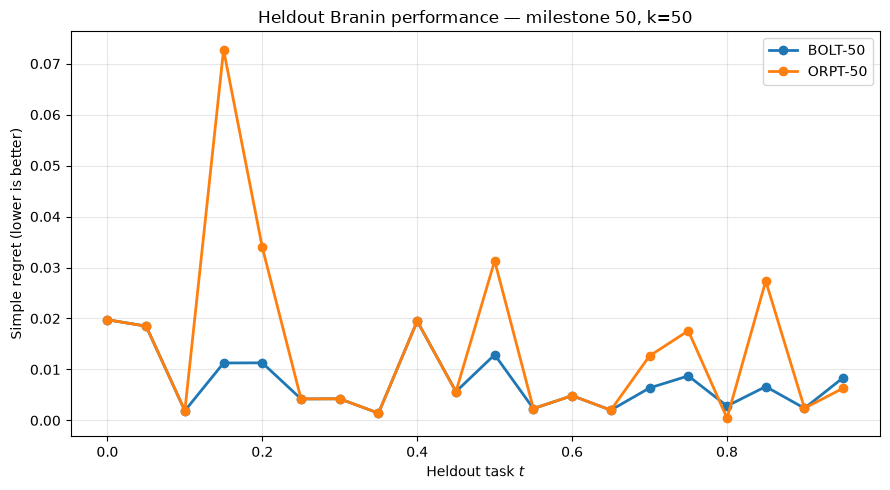

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for arm, group in selected.groupby('arm'):
    ax.plot(group.task_t, group[Y_COLUMN], marker='o', linewidth=2, label=arm)
ax.set_xlabel('Heldout task $t$')
ax.set_ylabel('Simple regret (lower is better)' if Y_COLUMN == 'simple_regret' else 'Best score (higher is better)')
ax.set_title(f'Heldout Branin performance — milestone {MILESTONE}, k={ORACLE_CALLS}')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = FIGURE_DIR / f'heldout_vs_t_m{MILESTONE}_k{ORACLE_CALLS}_{Y_COLUMN}.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
print('saved:', figure_path)
plt.show()

## Mean heldout performance by milestone
Each point is the mean over all heldout task $t$ values at the selected oracle-call budget. The shaded band is $\pm$ one standard error across heldout tasks.

In [11]:
import numpy as np

,method,milestone,mean_performance,std_performance,num_heldout_tasks,sem_performance
0,BOLT,2,0.011799,0.009983,20,0.002232
1,BOLT,5,0.011242,0.009182,20,0.002053
2,BOLT,10,0.009442,0.008571,20,0.001916
3,BOLT,20,0.008086,0.007660,20,0.001713
4,BOLT,30,0.007908,0.005779,20,0.001292
5,BOLT,40,0.007299,0.005952,20,0.001331
6,BOLT,50,0.007760,0.005985,20,0.001338
7,ORPT,2,0.011956,0.010037,20,0.002244
8,ORPT,5,0.008632,0.007427,20,0.001661
9,ORPT,10,0.008302,0.007595,20,0.001698


saved: /home/mok/orpt/BOLT/runs/synthetic_branin_100train_20heldout_bolt_vs_orpt_smaller/aggregate/heldout_mean_vs_milestone_k50_simple_regret.png


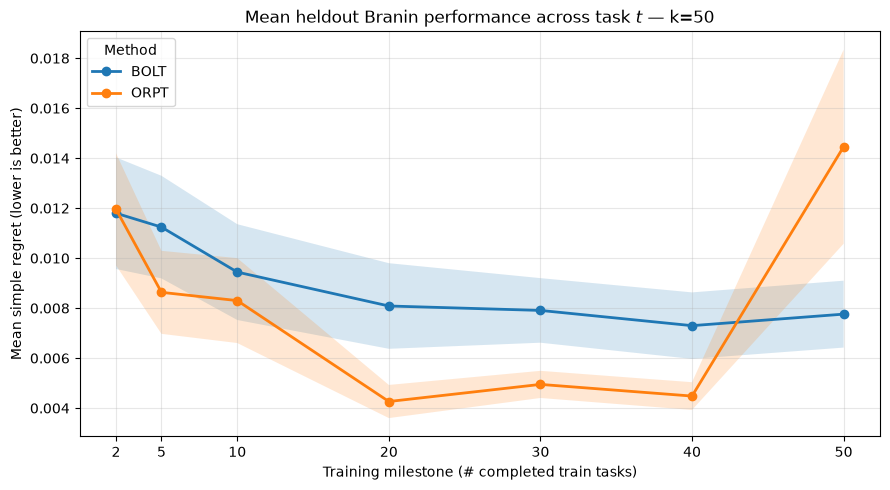

In [13]:
terminal = results[results.oracle_calls == ORACLE_CALLS].copy()
milestone_summary = (
    terminal.groupby(['method', 'milestone'], as_index=False)
    .agg(
        mean_performance=(Y_COLUMN, 'mean'),
        std_performance=(Y_COLUMN, 'std'),
        num_heldout_tasks=('task_t', 'nunique'),
    )
)
milestone_summary['sem_performance'] = (
    milestone_summary['std_performance'].fillna(0)
    / np.sqrt(milestone_summary['num_heldout_tasks'])
)
display(milestone_summary)

fig, ax = plt.subplots(figsize=(9, 5))
for method, group in milestone_summary.groupby('method'):
    group = group.sort_values('milestone')
    x = group['milestone'].to_numpy()
    mean = group['mean_performance'].to_numpy()
    sem = group['sem_performance'].to_numpy()
    ax.plot(x, mean, marker='o', linewidth=2, label=method)
    ax.fill_between(x, mean - sem, mean + sem, alpha=0.18)
ax.set_xlabel('Training milestone (# completed train tasks)')
ax.set_ylabel('Mean simple regret (lower is better)' if Y_COLUMN == 'simple_regret' else 'Mean best score (higher is better)')
ax.set_title(f'Mean heldout Branin performance across task $t$ — k={ORACLE_CALLS}')
ax.set_xticks(sorted(milestone_summary.milestone.unique()))
ax.grid(alpha=0.3)
ax.legend(title='Method')
fig.tight_layout()
figure_path = FIGURE_DIR / f'heldout_mean_vs_milestone_k{ORACLE_CALLS}_{Y_COLUMN}.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
print('saved:', figure_path)
plt.show()

,method,milestone,mean_performance,std_performance,num_heldout_tasks,sem_performance
0,BOLT,2,0.011799,0.009983,20,0.002232
1,BOLT,5,0.011242,0.009182,20,0.002053
2,BOLT,10,0.009442,0.008571,20,0.001916
3,BOLT,20,0.008086,0.007660,20,0.001713
4,BOLT,30,0.007908,0.005779,20,0.001292
5,BOLT,40,0.007299,0.005952,20,0.001331
6,BOLT,50,0.007760,0.005985,20,0.001338
7,ORPT,2,0.011956,0.010037,20,0.002244
8,ORPT,5,0.008632,0.007427,20,0.001661
9,ORPT,10,0.008302,0.007595,20,0.001698


saved: /home/mok/orpt/BOLT/runs/synthetic_branin_100train_20heldout_bolt_vs_orpt_smaller/aggregate/heldout_mean_vs_milestone_k50_simple_regret_revised.png


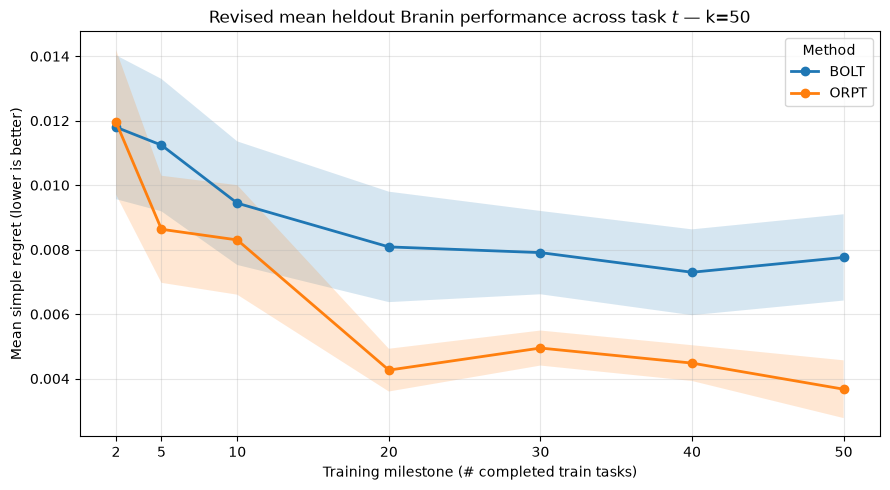

In [14]:
# Revised result after accepting split singleton-list outputs such as [x1]\n[x2].
import numpy as np

revised_frames = []
for expected_method, path in RESULT_PATHS.items():
    frame = pd.read_csv(path)
    frame = frame[frame['method'] == expected_method].copy()
    revised_frames.append(frame)
revised_results = pd.concat(revised_frames, ignore_index=True)

REVISED_ORACLE_CALLS = 50
revised_terminal = revised_results[
    revised_results.oracle_calls == REVISED_ORACLE_CALLS
].copy()
revised_summary = (
    revised_terminal.groupby(['method', 'milestone'], as_index=False)
    .agg(
        mean_performance=('simple_regret', 'mean'),
        std_performance=('simple_regret', 'std'),
        num_heldout_tasks=('task_t', 'nunique'),
    )
)
revised_summary['sem_performance'] = (
    revised_summary['std_performance'].fillna(0)
    / np.sqrt(revised_summary['num_heldout_tasks'])
)
display(revised_summary)

fig, ax = plt.subplots(figsize=(9, 5))
for method, group in revised_summary.groupby('method'):
    group = group.sort_values('milestone')
    x = group['milestone'].to_numpy()
    mean = group['mean_performance'].to_numpy()
    sem = group['sem_performance'].to_numpy()
    ax.plot(x, mean, marker='o', linewidth=2, label=method)
    ax.fill_between(x, mean - sem, mean + sem, alpha=0.18)
ax.set_xlabel('Training milestone (# completed train tasks)')
ax.set_ylabel('Mean simple regret (lower is better)')
ax.set_title(
    f'Revised mean heldout Branin performance across task $t$ '
    f'— k={REVISED_ORACLE_CALLS}'
)
ax.set_xticks(sorted(revised_summary.milestone.unique()))
ax.grid(alpha=0.3)
ax.legend(title='Method')
fig.tight_layout()
revised_figure_path = FIGURE_DIR / (
    f'heldout_mean_vs_milestone_k{REVISED_ORACLE_CALLS}_simple_regret_revised.png'
)
fig.savefig(revised_figure_path, dpi=200, bbox_inches='tight')
print('saved:', revised_figure_path)
plt.show()